In [1]:
import os
import re
import jsonlines
import duckdb
import polars as pl

from orqa.utils import sanitize_string

In [65]:
# in CAN la domanda 1038 ha la review che fa ridere
tag, from_, to_ = 'CAN', 0, 42705
tag, from_, to_ = 'UK', 0, 55556

data_path       = f'data'
tables_path     = f'{data_path}/datasets/{tag}/tables/tables_from{from_}_to{to_}'
metadata_path   = f'{data_path}/datasets/{tag}/metadata/metadata_from{from_}_to{to_}.jsonl'
db_path         = f'{data_path}/datasets/{tag}/database/blend.db'
valdict_path    = f'{data_path}/datasets/{tag}/database/values_dict.pickle'
log_path        = f'{data_path}/log/{tag}_JoinSearch.log'
candidates_path = f"{data_path}/outputs/{tag}/candidate_joins.csv"
evaluated_path  = f"{data_path}/outputs/{tag}/evaluated_joins.csv"
queries_path    = f"{data_path}/outputs/{tag}/{tag}_generated_queries_final.csv"
retq_path       = f"{data_path}/outputs/{tag}/queries.csv"

success_queries_path = f"{data_path}/outputs/{tag}/success_queries.csv"

In [129]:
import datetime
if tag == "UK":
    uk_blend_index_end              = datetime.datetime.strptime("2025-04-03 16:27:13", "%Y-%m-%d %H:%M:%S")
    uk_values_end                   = datetime.datetime.strptime("2025-04-03 17:28:20", "%Y-%m-%d %H:%M:%S")
    uk_index_re_start               = datetime.datetime.strptime("2025-04-04 11:50:04", "%Y-%m-%d %H:%M:%S")
    uk_blend_index_start            = datetime.datetime.strptime("2025-04-03 05:44:39", "%Y-%m-%d %H:%M:%S")
    blend_index_total_seconds       = ((uk_values_end - uk_blend_index_end)+ (uk_blend_index_start - uk_index_re_start)).total_seconds()

    uk_candidate_search_start       = datetime.datetime.strptime("2025-04-07 14:31:56", "%Y-%m-%d %H:%M:%S")
    uk_candidate_search_end         = datetime.datetime.strptime("2025-04-08 04:27:52", "%Y-%m-%d %H:%M:%S")
    candidate_search_total_seconds  = (uk_candidate_search_end - uk_candidate_search_start).total_seconds()
elif tag == "CAN":
    can_blend_index_end             = datetime.datetime.strptime("2025-04-02 17:10:55", "%Y-%m-%d %H:%M:%S")
    can_blend_index_start           = datetime.datetime.strptime("2025-04-03 05:44:39", "%Y-%m-%d %H:%M:%S")
    blend_index_total_seconds       = (can_blend_index_end - can_blend_index_start).total_seconds()

    can_candidate_search_start      = datetime.datetime.strptime("2025-04-03 10:00:50", "%Y-%m-%d %H:%M:%S")
    can_candidate_search_end        = datetime.datetime.strptime("2025-04-04 19:08:16", "%Y-%m-%d %H:%M:%S")
    candidate_search_total_seconds  = (can_candidate_search_end - can_candidate_search_start).total_seconds()

In [70]:
df = pl.read_csv(retq_path).filter(pl.col('success') == True)
(
    df
    .insert_column(0, pl.Series('country_tag', [tag] * len(df)))
    .unique(subset=['country_tag', 'type', 'difficulty', 'r_rsc_id', 's_rsc_id', 'r_pkg_id', 's_pkg_id', 'r_col_name', 's_col_name'])
    .with_columns(invalid=pl.col('nl').str.contains(r'dataset|record|table', literal=False))
    .filter(pl.col('invalid').not_())
    .drop('id', 'invalid')
    .sample(500)
    .write_csv(success_queries_path)
)

In [71]:
pl.read_csv(success_queries_path).unique(subset=['country_tag', 'type', 'difficulty', 'r_rsc_id', 's_rsc_id', 'r_pkg_id', 's_pkg_id', 'r_col_name', 's_col_name']).shape

(500, 26)

In [130]:
evaluations = pl.read_csv(evaluated_path)
evaluation_total_seconds = evaluations.select('time(s)').limit(10_000).sum()

In [131]:
generation_total_seconds = pl.read_csv(retq_path).select('tot_time').sum()

In [132]:
total_hours = (blend_index_total_seconds + candidate_search_total_seconds + evaluation_total_seconds + generation_total_seconds) / 3600
total_hours

time(s)
f64
40.839625


In [94]:
pl.read_csv(candidates_path, truncate_ragged_lines=True).shape, 

((59899, 14),)

In [36]:
pl.read_csv(retq_path).select('sql_time', 'sql_n_rev', 'nl_time', 'nl_n_rev', 'tot_time').describe()

statistic,sql_time,sql_n_rev,nl_time,nl_n_rev,tot_time
str,f64,f64,f64,f64,f64
"""count""",756.0,756.0,756.0,756.0,756.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",19.933893,0.89418,12.365443,0.427249,32.299336
"""std""",39.364596,1.252036,13.370605,1.21851,40.21409
"""min""",4.185,-1.0,-1.0,-1.0,5.698
"""25%""",7.042,0.0,5.767,0.0,14.958
"""50%""",9.192,0.0,7.892,0.0,23.269
"""75%""",27.007,2.0,13.199,0.0,41.045
"""max""",738.225,3.0,67.398,3.0,737.225


In [37]:
pl.read_csv(retq_path).filter(pl.col('success') == True).select('sql_time', 'sql_n_rev', 'nl_time', 'nl_n_rev', 'tot_time').describe()

statistic,sql_time,sql_n_rev,nl_time,nl_n_rev,tot_time
str,f64,f64,f64,f64,f64
"""count""",578.0,578.0,578.0,578.0,578.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",13.503945,0.519031,12.612931,0.491349,26.116875
"""std""",12.875726,0.965874,11.010573,1.01672,17.453043
"""min""",4.185,0.0,4.392,0.0,9.423
"""25%""",6.609,0.0,6.496,0.0,14.253
"""50%""",8.023,0.0,8.171,0.0,19.299
"""75%""",15.361,1.0,13.0,0.0,34.469
"""max""",142.006,3.0,63.517,3.0,150.27


In [6]:
pl.read_csv(retq_path).filter(pl.col('success') == False).select('sql_time', 'sql_n_rev', 'nl_time', 'nl_n_rev', 'tot_time').describe()

statistic,sql_time,sql_n_rev,nl_time,nl_n_rev,tot_time
str,f64,f64,f64,f64,f64
"""count""",83.0,83.0,83.0,83.0,83.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",40.670747,2.0,15.412084,0.650602,56.082831
"""std""",80.062687,1.343457,20.620535,1.883392,78.815994
"""min""",4.682,-1.0,-1.0,-1.0,8.846
"""25%""",16.723,0.0,-1.0,-1.0,29.992
"""50%""",30.325,3.0,-1.0,-1.0,46.581
"""75%""",44.249,3.0,30.451,3.0,59.06
"""max""",738.225,3.0,62.037,3.0,737.225


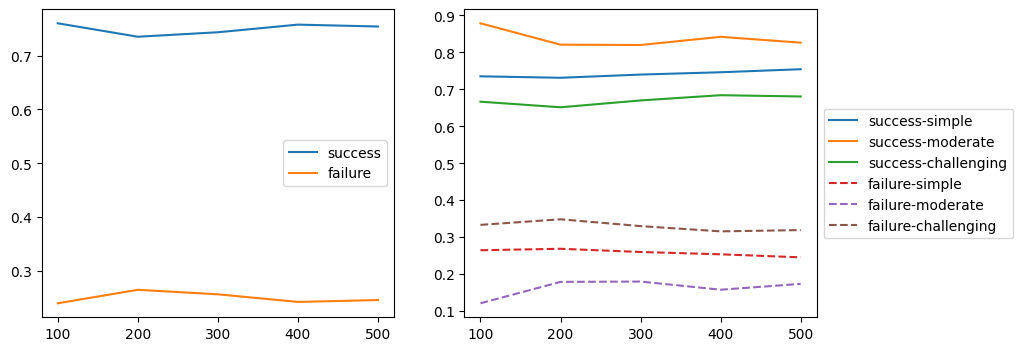

In [34]:
error_rates = []
df = pl.read_csv(retq_path).limit(1000)

for i in range(100, len(df), 100):
    success = df.limit(i).filter(pl.col('success') == True).shape[0] / i
    failure = df.limit(i).filter(pl.col('success') == False).shape[0] / i

    simple = df.limit(i).filter(pl.col('difficulty') == 'simple').shape[0]
    moderate = df.limit(i).filter(pl.col('difficulty') == 'moderate').shape[0]
    challenging = df.limit(i).filter(pl.col('difficulty') == 'challenging').shape[0]

    ss = df.limit(i).filter((pl.col('success') == True) & (pl.col('difficulty') == 'simple')).shape[0] / simple
    sm = df.limit(i).filter((pl.col('success') == True) & (pl.col('difficulty') == 'moderate')).shape[0] / moderate
    sc = df.limit(i).filter((pl.col('success') == True) & (pl.col('difficulty') == 'challenging')).shape[0] / challenging
    
    fs = df.limit(i).filter((pl.col('success') == False) & (pl.col('difficulty') == 'simple')).shape[0] / simple
    fm = df.limit(i).filter((pl.col('success') == False) & (pl.col('difficulty') == 'moderate')).shape[0] / moderate
    fc = df.limit(i).filter((pl.col('success') == False) & (pl.col('difficulty') == 'challenging')).shape[0] / challenging
    
    error_rates.append([i, success, failure, ss, sm, sc, fs, fm, fc])

import matplotlib.pyplot as plt

i, success, failure, ss, sm, sc, fs, fm, fc = list(zip(*error_rates))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(i, success, label='success')
ax1.plot(i, failure, label='failure')
ax1.legend()

ax2.plot(i, ss, label='success-simple')
ax2.plot(i, sm, label='success-moderate')
ax2.plot(i, sc, label='success-challenging')

ax2.plot(i, fs, '--', label='failure-simple')
ax2.plot(i, fm, '--', label='failure-moderate')
ax2.plot(i, fc, '--', label='failure-challenging')
ax2.legend(bbox_to_anchor=(1, 0.7))

In [47]:
#df = pl.read_csv(success_queries_path).filter(pl.col('success') == True).sample(500).group_by('difficulty').len()
df = pl.read_csv(success_queries_path).filter(pl.col('success') == True).group_by('difficulty').len()
df = pl.concat([df, pl.DataFrame({'difficulty': 'total', 'len': df.sum().get_column('len')})]).sort('difficulty')
df

difficulty,len
str,u32
"""challenging""",171
"""moderate""",189
"""simple""",140
"""total""",500


In [19]:
uk_df = pl.read_csv('data/outputs/UK/retrieval_queries_final.csv').filter(pl.col('success') == False).with_columns(pl.lit('UK').alias('tag')).limit(1000)
can_df = pl.read_csv('data/outputs/CAN/retrieval_queries_final.csv').filter(pl.col('success') == False).with_columns(pl.lit('CAN').alias('tag')).limit(1000)
df = (
    pl.concat([uk_df, can_df])
    .with_columns(
        sql_success=pl.col('sql_success').map_elements(lambda s: s if s == 'success' else re.match(r'(\w+ Error|[\w ,]+)', s).group(0), pl.String)
    )
)

df.pivot(on='tag', index=['sql_n_rev', 'sql_success'], values='id', aggregate_function='len').sort('sql_n_rev')

sql_n_rev,sql_success,UK,CAN
i64,str,u32,u32
-1,"""false""",6,17
0,"""success""",140,124
0,"""Empty result set""",3,null
0,"""Binder Error""",2,null
1,"""Parser Error""",2,2
…,…,…,…
3,"""Conversion Error""",38,12
3,"""Catalog Error""",11,4
3,"""the JSON object must be str, b…",6,5


In [91]:
df = pl.read_csv(retq_path).filter(pl.col('sql_success') == "success").group_by('type').len()
pl.concat([df, pl.DataFrame({'type': 'total', 'len': df.sum().get_column('len')})])

type,len
str,u32
"""multi-table-union""",77
"""multi-table-join""",103
"""single-join""",331
"""total""",511


In [21]:
uk_df = pl.read_csv('data/outputs/UK/retrieval_queries_final.csv').filter(pl.col('success') == True).with_columns(pl.lit('UK').alias('tag')).limit(1000)
can_df = pl.read_csv('data/outputs/CAN/retrieval_queries_final.csv').filter(pl.col('success') == True).with_columns(pl.lit('CAN').alias('tag')).limit(1000)
df = pl.concat([uk_df, can_df])
df = df.with_columns(mode=pl.col('type').map_elements(lambda s: 'single' if s == 'single-table' else 'multi', pl.String))
pivot = df.pivot(on='tag', index=['difficulty', 'mode'], values='id', aggregate_function='len')
#pivot = pl.concat([pivot, pl.DataFrame({'difficulty': 'total', 'UK': pivot.select('UK').sum(), 'CAN': pivot.select('CAN').sum()})])
pivot = pivot.with_columns(UK=pl.col('UK') / 1000, CAN=pl.col('CAN') / 1000)
pivot

difficulty,mode,UK,CAN
str,str,f64,f64
"""challenging""","""single""",0.202,0.139
"""simple""","""single""",0.193,0.107
"""moderate""","""single""",0.232,0.143
"""simple""","""multi""",0.127,0.044
"""moderate""","""multi""",0.122,0.039
"""challenging""","""multi""",0.124,0.04


In [75]:
(
    pl.read_csv('data/outputs/orqa_dataset_v0.csv')
    .with_columns(mode=pl.col('type').map_elements(lambda s: 'single' if s == 'single-table' else 'multi', pl.String), no_col=pl.lit('test'))
    .pivot(index=['difficulty', 'mode'], on='no_col', values='success', aggregate_function='len')    
)


difficulty,mode,test
str,str,u32
"""simple""","""single""",208
"""moderate""","""multi""",97
"""challenging""","""single""",236
"""moderate""","""single""",272
"""challenging""","""multi""",83
"""simple""","""multi""",104


In [72]:
pl.read_csv('data/outputs/orqa_dataset_v0.csv').unique(subset=['country_tag', 'type', 'difficulty', 'r_rsc_id', 's_rsc_id', 'r_pkg_id', 's_pkg_id', 'r_col_name', 's_col_name']).shape

(1000, 26)

In [ ]:
pivot = df.pivot(on='tag', index=['difficulty', 'type'], values='id', aggregate_function='len')
pivot

difficulty,type,UK,CAN
str,str,u32,u32
"""simple""","""single-join""",168,101
"""moderate""","""single-join""",172,106
"""challenging""","""single-join""",101,64
"""simple""","""multi-table-union""",74,29
"""moderate""","""multi-table-union""",51,17
"""challenging""","""multi-table-union""",39,21
"""simple""","""multi-table-join""",142,82
"""moderate""","""multi-table-join""",142,61
"""challenging""","""multi-table-join""",115,60


In [32]:
df.select('sql_n_rev', 'nl_n_rev', 'difficulty').group_by('difficulty', maintain_order=True).agg(pl.col('sql_n_rev').mean(), pl.col('sql_n_rev').std().alias('sql_std'), pl.col('nl_n_rev').mean(), pl.col('nl_n_rev').std().alias('nl_std'))

difficulty,sql_n_rev,sql_std,nl_n_rev,nl_std
str,f64,f64,f64,f64
"""simple""",0.464646,0.919856,0.178451,0.579417
"""moderate""",0.676417,1.107522,0.078611,0.414083
"""challenging""",0.94,1.142218,0.105,0.514428


In [3]:
table_ids = list(sorted(os.listdir(tables_path), reverse=True))
len(table_ids)

31437

In [8]:
# 2131,3376
r, s = "d91e4d93-8c0e-43d9-bfc4-6cc83c0164de,d859208e-6551-497a-8b9c-3da9e1c0aaa2".split(',')
table_ids.index(r + '.parquet'), table_ids.index(s + '.parquet')

(4224, 4294)

In [7]:
import json
with open(queries_path, 'r') as file:
    queries = json.load(file)

In [53]:
can = pl.read_csv('data/outputs/CAN/evaluated_joins.csv').sample(1000)
uk = pl.read_csv('data/outputs/UK/evaluated_joins.csv').sample(1000)

# Create a list of thresholds from -1 to 10
thresholds = list(range(-1, 11))

# Create a DataFrame of results
uk = pl.DataFrame({
    "threshold": thresholds
}).with_columns([
    pl.col("threshold").map_elements(
        lambda x: uk.filter(pl.col("score") >= x).height, pl.Int32
    ).alias("count_above"),
    pl.col("threshold").map_elements(
        lambda x: round(uk.filter(pl.col("score") >= x).height / uk.shape[0], 3), pl.Float32
    ).alias("count_above(%)")
])

# Create a DataFrame of results
can = pl.DataFrame({
    "threshold": thresholds
}).with_columns([
    pl.col("threshold").map_elements(
        lambda x: can.filter(pl.col("score") >= x).height, pl.Int32
    ).alias("count_above"),
    pl.col("threshold").map_elements(
        lambda x: round(can.filter(pl.col("score") >= x).height / can.shape[0], 3), pl.Float32
    ).alias("count_above(%)")
])

In [60]:
uk.join(can, on='threshold', suffix="_can")[5:]

threshold,count_above,count_above(%),count_above_can,count_above(%)_can
i64,i32,f32,i32,f32
4,969,0.969,910,0.91
5,962,0.962,865,0.865
6,952,0.952,807,0.807
7,938,0.938,755,0.755
8,806,0.806,551,0.551
9,160,0.16,256,0.256
10,0,0.0,0,0.0


In [57]:
uk.plot.bar(x='threshold', y='count_above')
can.plot.bar(x='threshold', y='count_above')

alt.Chart(...)

In [58]:
from scipy import stats

# Example values
mean_diff = 0.43
std_diff = 1.45
n = 100

# t-statistic
t_stat = mean_diff / (std_diff / (n**0.5))
df = n - 1

# two-tailed p-value
p_value = 2 * stats.t.sf(abs(t_stat), df)
print(p_value)


0.00378697025718062


In [24]:
from tqdm import tqdm

# compute average size
tot_r, tot_c = [], []
for p in tqdm(table_ids):
    r, c = pl.read_parquet(f'{tables_path}/{p}').shape
    tot_r.append(r)
    tot_c.append(c)

100%|██████████| 31437/31437 [07:52<00:00, 66.48it/s] 


In [25]:
from statistics import mean, stdev

print(f'mean rows: {mean(tot_r)} +-{stdev(tot_r)}')
print(f'mean cols: {mean(tot_c)} +-{stdev(tot_c)}')

mean rows: 141714.06880427522 +-1405456.4214871745
mean cols: 17.42297292998696 +-168.58436753900466


In [2]:
# in CAN la domanda 1038 ha la review che fa ridere
tag, from_, to_ = 'UK', 0, 55556
tag, from_, to_ = 'CAN', 0, 42705

data_path       = f'data'
tables_path     = f'{data_path}/datasets/{tag}/tables/tables_from{from_}_to{to_}'
metadata_path   = f'{data_path}/datasets/{tag}/metadata/metadata_from{from_}_to{to_}.jsonl'
db_path         = f'{data_path}/datasets/{tag}/database/blend.db'
valdict_path    = f'{data_path}/datasets/{tag}/database/values_dict.pickle'
log_path        = f'{data_path}/log/{tag}_JoinSearch.log'
candidates_path = f"{data_path}/outputs/{tag}/candidate_joins_test.csv"
evaluated_path  = f"{data_path}/outputs/{tag}/evaluated_joins_test.csv"
queries_path    = f"{data_path}/outputs/{tag}/{tag}_generated_queries_final.csv"
retq_path       = f"{data_path}/outputs/{tag}/queries.csv"

In [3]:
table_ids = list(sorted(os.listdir(tables_path), reverse=True))

In [4]:
from orqa.utils import get_resource_metadata

with jsonlines.open(metadata_path) as fr:
    metadata = {rsc['id']: md for md in fr.iter() for rsc in md['resources'] if rsc['format'] == 'CSV'}

In [27]:
rid, sid = "d91e4d93-8c0e-43d9-bfc4-6cc83c0164de,d859208e-6551-497a-8b9c-3da9e1c0aaa2".split(',')
r_df = pl.read_parquet(f"{tables_path}/{rid}.parquet").rename(lambda s: sanitize_string(s, "complex"))
s_df = pl.read_parquet(f"{tables_path}/{sid}.parquet").rename(lambda s: sanitize_string(s, "complex"))
print(r_df.columns)
print(s_df.columns)
r_df.shape, s_df.shape, table_ids.index(rid + '.parquet'), table_ids.index(sid + '.parquet')

['i_ref_date_', 'geo', 'dguid', 'indicators', 'industry', 'uom', 'uom_id', 'scalar_factor', 'scalar_id', 'vector', 'coordinate', 'value', 'status', 'symbol', 'terminated', 'decimals']
['i_ref_date_', 'geo', 'dguid', 'indicators', 'domain', 'uom', 'uom_id', 'scalar_factor', 'scalar_id', 'vector', 'coordinate', 'value', 'status', 'symbol', 'terminated', 'decimals']


((25155, 16), (9828, 16), 4224, 4294)

In [28]:
table_ids[30772]

'027ecdf8-4b63-4971-87e0-4a818139fcc2.parquet'

In [29]:
from pprint import pprint

print(metadata[rid]['title'])
pprint(metadata[rid]['notes'])

print(metadata[sid]['title'])
pprint(metadata[sid]['notes'])

Culture and sport indicators by domain and sub-domain, by province and territory, industry perspective
('<p>Gross domestic product, output and jobs for sport and culture, industry '
 'perspective, annual.<br></p>')
National culture and sport indicators by domain and sub-domain
('<p>Gross domestic product, output and jobs for sport and culture, product '
 'perspective, quarterly.<br>\n'
 '</p>\n')


In [30]:
from pprint import pprint

# polars df-to-str configuration
pl_str_config = {
    'tbl_hide_dataframe_shape': True,
    'tbl_width_chars': 1000,
    'tbl_formatting': 'MARKDOWN',
    'tbl_cols': 20
}

pprint(metadata[rid])

{'association_type': [],
 'audience': [],
 'author': None,
 'author_email': 'infostats@statcan.gc.ca',
 'collection': 'primary',
 'contributor': {},
 'creator_user_id': '6b600515-c266-4584-a219-d084c980fd47',
 'data_series_issue_identification': {'en': 'Table 36100453; Formerly CANSIM '
                                            'Table 387-0013',
                                      'fr': 'Tableau 36100453; Anciennement '
                                            'Table CANSIM 387-0013'},
 'data_series_name': {'en': 'Table', 'fr': 'Tableau'},
 'date_published': '2024-06-03 08:30:00',
 'display_flags': [],
 'frequency': 'P1Y',
 'geographic_region': [],
 'groups': [],
 'id': '86ac4b30-c367-4235-83eb-b6cbd951cb1d',
 'imso_approval': 'true',
 'isopen': False,
 'jurisdiction': 'federal',
 'keywords': {'en': ['business and consumer services',
                     'business and consumer services and culture',
                     'culture',
                     'culture accounts',
       

In [32]:
r = set(map(tuple, r_df.select(r_df.columns[:3]).rows()))
s = set(map(tuple, s_df.select(s_df.columns[:3]).rows()))
len(r.intersection(s)), len(r), len(s)

(0, 195, 51)

In [ ]:
# d91e4d93-8c0e-43d9-bfc4-6cc83c0164de
# d859208e-6551-497a-8b9c-3da9e1c0aaa2
df = pl.read_parquet(f"{tables_path}/{rid}.parquet").rename(lambda s: sanitize_string(s, "complex"))# .select(pl.all().map_elements(sanitize_string, pl.String))        
df = df[[c for c in df.columns if df[c].is_null().sum() < df.shape[0]]]
R = df
df.head()

i_ref_date_,geo,dguid,age_group,sex,uom,uom_id,scalar_factor,scalar_id,vector,coordinate,value,decimals
i64,str,str,str,str,str,i64,str,i64,str,str,i64,i64
2001,"""Canada""","""0""","""Total, all ages""","""Both sexes""","""Number""",223,"""units """,0,"""v96270237""","""1.1.1""",31020596,0
2001,"""Canada""","""0""","""Total, all ages""","""Males""","""Number""",223,"""units """,0,"""v96270238""","""1.1.2""",15366390,0
2001,"""Canada""","""0""","""Total, all ages""","""Females""","""Number""",223,"""units """,0,"""v96270239""","""1.1.3""",15654206,0
2001,"""Canada""","""0""","""Under 1 year""","""Both sexes""","""Number""",223,"""units """,0,"""v96270240""","""1.2.1""",331875,0
2001,"""Canada""","""0""","""Under 1 year""","""Males""","""Number""",223,"""units """,0,"""v96270241""","""1.2.2""",170145,0
…,…,…,…,…,…,…,…,…,…,…,…,…
2014,"""Peer group I""","""I""","""89 years""","""Males""","""Number""",223,"""units """,0,"""v96320062""","""151.109.2""",216,0
2014,"""Peer group I""","""I""","""89 years""","""Females""","""Number""",223,"""units """,0,"""v96320063""","""151.109.3""",310,0
2014,"""Peer group I""","""I""","""90 years and over""","""Both sexes""","""Number""",223,"""units """,0,"""v96320064""","""151.110.1""",2136,0


In [52]:
df = pl.read_parquet(f"{tables_path}/e024a03c-7e13-4da2-a551-70efd1b9347b.parquet").rename(lambda s: sanitize_string(s, "complex"))# .select(pl.all().map_elements(sanitize_string, pl.String))        
df = df[[c for c in df.columns if df[c].is_null().sum() < df.shape[0]]]
S = df
df.sample(10)

ilsoa21_cd,lsoa21_nm,lep22_cd1,lep22_nm1,lep22_cd2,lep22_nm2,object_id
str,str,str,str,str,str,i64
"""E01021420""","""Braintree 017C""","""E37000056""","""South East""",null,null,20306
"""E01035525""","""Cambridge 015B""","""E37000059""","""The Business Board""",null,null,33412
"""E01015655""","""Peterborough 014E""","""E37000059""","""The Business Board""",null,null,14965
"""E01012997""","""East Riding of Yorkshire 040B""","""E37000061""","""Hull and East Yorkshire""",null,null,12391
"""E01013563""","""Derby 019E""","""E37000045""","""D2N2""",null,null,12978
"""E01007912""","""Sheffield 037B""","""E37000054""","""South Yorkshire""",null,null,7317
"""E01012686""","""Blackpool 014A""","""E37000019""","""Lancashire""",null,null,12096
"""E01028668""","""South Oxfordshire 001C""","""E37000053""","""OxLEP""",null,null,27421
"""E01025972""","""Oadby and Wigston 003C""","""E37000021""","""Leicester and Leicestershire""",null,null,24468


In [26]:
with pl.Config(**pl_str_config):
    print(r_df.sample(10))
    print()
    print(s_df.sample(10))

| i_ref_date_ | geo                             | dguid            | property_type             | period_of_construction          | residency_status                | estimates     | uom     | uom_id | scalar_factor | scalar_id | vector     | coordinate  | value      | status | symbol | terminated | decimals |
| ---         | ---                             | ---              | ---                       | ---                             | ---                             | ---           | ---     | ---    | ---           | ---       | ---        | ---         | ---        | ---    | ---    | ---        | ---      |
| i64         | str                             | str              | str                       | str                             | str                             | str           | str     | i64    | str           | i64       | str        | str         | f64        | str    | f64    | f64        | i64      |
|-------------|---------------------------------|------------------|--

In [131]:
import duckdb

duckdb.query(
"SELECT R.organization, SUM(CAST(REPLACE(R.amount, ',', '') AS INTEGER)) AS total_amount, COUNT(S.i_fy_ef_) AS document_count FROM R JOIN S ON R.organization = S.organization GROUP BY R.organization;"
)

┌─────────────────────────────────────────────────────────────────┬──────────────┬────────────────┐
│                          organization                           │ total_amount │ document_count │
│                             varchar                             │    int128    │     int64      │
├─────────────────────────────────────────────────────────────────┼──────────────┼────────────────┤
│ Courts Administration Service                                   │     34318584 │             18 │
│ Atlantic Canada Opportunities Agency                            │    311038380 │            360 │
│ Atomic Energy of Canada Limited                                 │     10450000 │             19 │
│ Canada Border Services Agency                                   │    201170924 │            488 │
│ Department of Employment and Social Development                 │  13134514738 │            820 │
│ Department of Natural Resources                                 │   3513544282 │           2214 │


In [176]:
"SELECT `position_/_poste`, SUM(CAST(REGEXP_REPLACE(""amount_/_montant"", '[^0-9.]', '') AS FLOAT)) AS total_amount FROM r_df GROUP BY ""position_/_poste"""

"SELECT `position_/_poste`, SUM(CAST(REGEXP_REPLACE(amount_/_montant, '[^0-9.]', '') AS FLOAT)) AS total_amount FROM r_df GROUP BY position_/_poste"

In [8]:
for column in r_df.columns:
    try:
        dtype = pl.Float32 if any(',' in str(x) or '.' in str(x) for x in set(r_df.select(column).sample(1000, with_replacement=True).to_series())) else pl.Int32
        r_df: pl.DataFrame = r_df.with_columns(pl.col(column).cast(dtype))
    except:
        continue

with pl.Config(tbl_width_chars=1000, tbl_cols=20):
    s = str(r_df)
print(s)

shape: (436_968, 15)
┌─────────────┬─────────────────────────────┬────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────┬────────┬───────────────┬───────────┬─────────────┬────────────┬───────────┬────────┬──────────┐
│ i_ref_date_ ┆ geo                         ┆ dguid          ┆ persons_in_low_income           ┆ low_income_lines                ┆ statistics                      ┆ uom     ┆ uom_id ┆ scalar_factor ┆ scalar_id ┆ vector      ┆ coordinate ┆ value     ┆ status ┆ decimals │
│ ---         ┆ ---                         ┆ ---            ┆ ---                             ┆ ---                             ┆ ---                             ┆ ---     ┆ ---    ┆ ---           ┆ ---       ┆ ---         ┆ ---        ┆ ---       ┆ ---    ┆ ---      │
│ i32         ┆ str                         ┆ str            ┆ str                             ┆ str                             ┆ str                             ┆ s

In [26]:
r_df

i_ref_date_,geo,dguid,persons_in_low_income,low_income_lines,statistics,uom,uom_id,scalar_factor,scalar_id,vector,coordinate,value,status,decimals
i32,str,str,str,str,str,str,i32,str,i32,str,str,f32,str,i32
1976,"""Canada""","""2021A000011124""","""All persons""","""Low income measure after tax""","""Number of persons in low incom…","""Number""",223,"""thousands""",3,"""v96515825""","""1.1.1.1""",3008.0,null,0
1976,"""Canada""","""2021A000011124""","""All persons""","""Low income measure after tax""","""Percentage of persons in low i…","""Percent""",239,"""units""",0,"""v96515826""","""1.1.1.2""",13.0,null,1
1976,"""Canada""","""2021A000011124""","""All persons""","""Low income measure after tax""","""Average gap ratio""","""Percent""",239,"""units""",0,"""v96515827""","""1.1.1.3""",31.6,null,1
1976,"""Canada""","""2021A000011124""","""All persons""","""Low income cut-offs after tax,…","""Number of persons in low incom…","""Number""",223,"""thousands""",3,"""v96515828""","""1.1.2.1""",2989.0,null,0
1976,"""Canada""","""2021A000011124""","""All persons""","""Low income cut-offs after tax,…","""Percentage of persons in low i…","""Percent""",239,"""units""",0,"""v96515829""","""1.1.2.2""",13.0,null,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2022,"""Vancouver, British Columbia""","""2021S0503933""","""Non-elderly females not in an …","""Low income cut-offs before tax…","""Percentage of persons in low i…","""Percent""",239,"""units""",0,"""v96524388""","""21.34.3.2""",33.200001,"""C""",1
2022,"""Vancouver, British Columbia""","""2021S0503933""","""Non-elderly females not in an …","""Low income cut-offs before tax…","""Average gap ratio""","""Percent""",239,"""units""",0,"""v96524389""","""21.34.3.3""",49.799999,"""C""",1
2022,"""Vancouver, British Columbia""","""2021S0503933""","""Non-elderly females not in an …","""Market basket measure, 2018 ba…","""Number of persons in low incom…","""Number""",223,"""thousands""",3,"""v1206134333""","""21.34.6.1""",61.0,"""D""",0


In [9]:
from orqa.utils import create_table_sql
create_table_sql(r_df, 'R')

("CREATE TABLE R (\n    ('i_ref_date_', {'BIGINT'}),\n    ('geo', {'VARCHAR(255)'}),\n    ('dguid', {'VARCHAR(255)'}),\n    ('persons_in_low_income', {'VARCHAR(255)'}),\n    ('low_income_lines', {'VARCHAR(255)'}),\n    ('statistics', {'VARCHAR(255)'}),\n    ('uom', {'VARCHAR(255)'}),\n    ('uom_id', {'BIGINT'}),\n    ('scalar_factor', {'VARCHAR(255)'}),\n    ('scalar_id', {'BIGINT'}),\n    ('vector', {'VARCHAR(255)'}),\n    ('coordinate', {'VARCHAR(255)'}),\n    ('value', {'FLOAT'}),\n    ('status', {'VARCHAR(255)'}),\n    ('decimals', {'BIGINT'})\n);",
 [('i_ref_date_', 'BIGINT'),
  ('geo', 'VARCHAR(255)'),
  ('dguid', 'VARCHAR(255)'),
  ('persons_in_low_income', 'VARCHAR(255)'),
  ('low_income_lines', 'VARCHAR(255)'),
  ('statistics', 'VARCHAR(255)'),
  ('uom', 'VARCHAR(255)'),
  ('uom_id', 'BIGINT'),
  ('scalar_factor', 'VARCHAR(255)'),
  ('scalar_id', 'BIGINT'),
  ('vector', 'VARCHAR(255)'),
  ('coordinate', 'VARCHAR(255)'),
  ('value', 'FLOAT'),
  ('status', 'VARCHAR(255)'),
  ('d

In [203]:
r_df.select('date_of_payment').cast(pl.Date)

InvalidOperationError: conversion from `str` to `date` failed in column 'date_of_payment' for 4093 out of 4093 values: ["01/06/2017", "01/06/2017", … "12/06/2017"]

You might want to try:
- setting `strict=False` to set values that cannot be converted to `null`
- using `str.strptime`, `str.to_date`, or `str.to_datetime` and providing a format string

In [199]:
r_df.select('amount_in_sterling').sort(by='amount_in_sterling')

amount_in_sterling
str
"""0.30"""
"""1,000,000.00"""
"""1,000,000.00"""
"""1,000,000.00"""
"""1,004,385.00"""
…
"""_917.00"""
"""_917.00"""
"""_927.00"""


In [ ]:
r_df.filter((pl.col('group') == 'tax_measure_other_than_tax_expenditure') & (pl.col('2014') == ""))
# logging_tax_credit

measure,group,subject,category,tax,details,2013,2014,2015,2016,2017,2018,2019,2020,unnamed:_14,unnamed:_15,unnamed:_16,unnamed:_17
str,str,str,str,str,str,str,str,str,str,str,str,str,str,i32,i32,i32,i32


In [43]:
groups = r_df.select('group').unique().to_series().to_list()
groups

['tax_measure_other_than_tax_expenditure',
 'refundable_tax_credit_classified_as_transfer_payment',
 None,
 'tax_expenditure']

In [62]:
r_df.filter(pl.col('measure') == 'logging_tax_credit')
r_df.filter(pl.col('measure') == 'employee_benefit_plans')
r_df.filter(pl.col('measure') == 'canada_child_benefit')

measure,group,subject,category,tax,details,2013,2014,2015,2016,2017,2018,2019,2020,unnamed:_14,unnamed:_15,unnamed:_16,unnamed:_17
str,str,str,str,str,str,str,str,str,str,str,str,str,str,i32,i32,i32,i32
"""canada_child_benefit""","""refundable_tax_credit_classifi…",null,null,"""pit""","""personal_income_tax""","""""","""""","""""","""16860""","""23420""","""23900""","""24200""","""24700""",null,null,null,null


In [39]:
measures = r_df.select('measure').unique().to_series().to_list()
measures

['canada_child_tax_benefit',
 'dividend_gross_up_and_tax_credit',
 'special_tax_rate_for_credit_unions',
 'exemption_of_scholarship,_fellowship_and_bursary_income',
 'non_taxation_of_guaranteed_income_supplement_and_allowance_benefits',
 'deduction_of_allowable_business_investment_losses',
 'deduction_of_other_employment_expenses',
 'deductibility_of_earthquake_reserves',
 'expensing_of_current_expenditures_on_scientific_research_and_experimental_development',
 'inclusion_of_the_universal_child_care_benefit_in_the_income_of_an_eligible_dependant',
 'exemption_from_gst_for_sales_of_used_residential_housing_and_other_personal_use_real_property',
 'registered_retirement_savings_plans',
 'non_taxation_of_capital_gains_on_donations_of_publicly_listed_securities',
 'lifetime_capital_gains_exemption',
 'zero_rating_of_feminine_hygiene_products',
 'non_taxation_of_allowances_for_members_of_legislative_assemblies_and_certain_municipal_officers',
 'deferred_profit_sharing_plans',
 'accelerated_d

In [33]:
r_df

measure,group,subject,category,tax,details,2013,2014,2015,2016,2017,2018,2019,2020,unnamed:_14,unnamed:_15,unnamed:_16,unnamed:_17
str,str,str,str,str,str,str,str,str,str,str,str,str,str,i32,i32,i32,i32
"""$200_capital_gains_exemption_o…","""tax_expenditure""","""savings_and_investment""","""structural""","""pit""","""personal_income_tax""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""",null,null,null,null
"""accelerated_capital_cost_allow…","""tax_expenditure""","""environment""","""non_structural""","""pit/cit""","""total""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""",null,null,null,null
"""accelerated_capital_cost_allow…","""tax_expenditure""","""environment""","""non_structural""","""pit""","""personal_income_tax""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""",null,null,null,null
"""accelerated_capital_cost_allow…","""tax_expenditure""","""environment""","""non_structural""","""cit""","""corporate_income_tax""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""",null,null,null,null
"""accelerated_capital_cost_allow…","""tax_expenditure""","""business___natural_resources""","""non_structural""","""pit/cit""","""total""","""s""","""s""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""","""n.a.""",null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""zero_rating_of_basic_groceries""","""tax_expenditure""","""social""","""non_structural""","""gst""","""goods_and_services_tax""","""3895""","""4080""","""4235""","""4380""","""4550""","""4720""","""4885""","""4950""",null,null,null,null
"""zero_rating_of_feminine_hygien…","""tax_expenditure""","""families_and_households""","""non_structural""","""gst""","""goods_and_services_tax""","""""","""""","""15""","""35""","""35""","""40""","""40""","""40""",null,null,null,null
"""zero_rating_of_medical_and_ass…","""tax_expenditure""","""health""","""non_structural""","""gst""","""goods_and_services_tax""","""335""","""360""","""375""","""395""","""405""","""415""","""430""","""440""",null,null,null,null


In [46]:
import duckdb
duckdb.query(
    "SELECT measure, \"group\", sum(CASE WHEN regexp_matches(\"2013\", '^\\d+$') THEN CAST(\"2013\" AS INTEGER) ELSE 0 END) AS total_2013 FROM r_df GROUP BY measure, \"group\""
)

┌───────────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────┬────────────┐
│                                        measure                                        │                        group                         │ total_2013 │
│                                        varchar                                        │                       varchar                        │   int128   │
├───────────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────┼────────────┤
│ capital_loss_carry_overs                                                              │ tax_measure_other_than_tax_expenditure               │       1700 │
│ deferral_through_five_year_capital_gain_reserve                                       │ tax_expenditure                                      │         10 │
│ deferred_profit_sharing_plans                     

In [74]:
r_df

i_program_//_programme_,commodity_//_produit,sample_plan_number_//_numaro_du_plan_d'achantillonnage,sample_plan_description_//_description_du_plan_d'achantillonnage,system_id_//_numaro_d'identification,date_sampled_//_date_d'achantillonnage,country_of_origin_//_pays_d'origine,product_description_//_description_du_produit,analysis___description_//_description_de_l'analyse,method_number_//_numaro_de_la_mathode,result_//_rasultat,result___unit_//_rasultat___unita,analysis_assessment_//_avaluation_de_l'analyse
str,str,str,str,str,str,str,str,str,str,str,str,str
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d210""","""imported_dairy_products_//_pro…","""2016_fdy_0000021772_4""","""2016_04_14""","""united_states_//_atats_unis""","""raw_milk_cheese_//_fromage_de_…","""listeria_monocytogenes""","""mfhpb_30""","""not_detected_/_125_grams///non…","""not_applicable_//_sans_objet""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d210""","""imported_dairy_products_//_pro…","""2016_fdy_0000021772_4""","""2016_04_14""","""united_states_//_atats_unis""","""raw_milk_cheese_//_fromage_de_…","""salmonella""","""mflp_29""","""not_detected_/_125_grams///non…","""not_applicable_//_sans_objet""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d210""","""imported_dairy_products_//_pro…","""2016_fdy_0000021772_4""","""2016_04_14""","""united_states_//_atats_unis""","""raw_milk_cheese_//_fromage_de_…","""staphylococcus_aureus___count_…","""mfhpb_21""","""<25""","""cfu_per_g/ml_//_ufc_par_g/ml""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d210""","""imported_dairy_products_//_pro…","""2016_fdy_0000021772_4""","""2016_04_14""","""united_states_//_atats_unis""","""raw_milk_cheese_//_fromage_de_…","""staphylococcal_enterotoxins_//…","""mflp_65""","""not_detected_/_25_grams///non_…","""not_applicable_//_sans_objet""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d210""","""imported_dairy_products_//_pro…","""2016_fdy_0000021772_4""","""2016_04_14""","""united_states_//_atats_unis""","""raw_milk_cheese_//_fromage_de_…","""e._coli""","""mfhpb_19""","""<1.8""","""mpn_per_g/ml_//_npp_par_g/ml""","""satisfactory_//_satisfaisant"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d207""","""domestic_cheese_//_fromage_can…","""2017_fdy_0000020716_4""","""2017_03_31""","""canada""","""pasteurized_milk_cheese_//_fro…","""salmonella""","""mflp_40""","""not_detected_/_125_grams///non…","""not_applicable_//_sans_objet""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d207""","""domestic_cheese_//_fromage_can…","""2017_fdy_0000020716_4""","""2017_03_31""","""canada""","""pasteurized_milk_cheese_//_fro…","""staphylococcal_enterotoxins_//…","""mflp_65""","""not_detected_/_25_grams///non_…","""not_applicable_//_sans_objet""","""satisfactory_//_satisfaisant"""
"""nmmp_//_pnsm""","""dairy_products_//_produit_lait…","""2016_d207""","""domestic_cheese_//_fromage_can…","""2017_fdy_0000020716_4""","""2017_03_31""","""canada""","""pasteurized_milk_cheese_//_fro…","""e._coli""","""mfhpb_34""","""<5""","""cfu_per_g/ml_//_ufc_par_g/ml""","""satisfactory_//_satisfaisant"""
